# IndicCorp V2 — Sentence Tokenization, BPE vs WordPiece

**Language used:** Hindi (`hin_Deva` split of `ai4bharat/IndicCorpV2`). Change `LANG_SPLIT` in the config cell to switch languages (e.g. `guj_Gujr`, `mar_Deva`, `tam_Taml`).

Pipeline:
1. Download raw paragraphs, sentence-tokenize into a flat sentence list.
2. Build length-stratified dev/test sets (1000 sentences each) + train set.
3. Train BPE and WordPiece tokenizers with `tokenizers` (HuggingFace) at multiple training-data sizes and vocab sizes.
4. Evaluate tokenization (avg tokens/sentence, fertility, unknown-token rate) on dev/test.


In [ ]:
!pip install -q datasets tokenizers indic-nlp-library matplotlib pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 9.3 MB/s eta 0:00:00


In [ ]:
import os, re, json, random, math
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset
from tokenizers import Tokenizer, normalizers, pre_tokenizers, decoders
from tokenizers.models import BPE, WordPiece
from tokenizers.trainers import BpeTrainer, WordPieceTrainer

random.seed(42)


## 1. Config

In [ ]:
LANG_SPLIT   = "hin_Deva"      # IndicCorpV2 split name for the language
DEV_SIZE     = 1000
TEST_SIZE    = 1000
MIN_WORDS    = 4               # drop very short/junk sentences
MAX_WORDS    = 120             # drop pathologically long lines
MAX_PARAGRAPHS = 300000        # how many raw paragraphs to pull from the corpus (streaming)

TRAIN_SIZES  = [100000, 300000, 500000, 1000000]   # task 3
VOCAB_SIZES  = [20000, 30000, 50000]                # task 4
DEFAULT_VOCAB_SIZE = 30000     # used when varying train size
DEFAULT_TRAIN_SIZE = 1000000   # used when varying vocab size (capped to available data)

OUT_DIR = "indiccorp_data"
os.makedirs(OUT_DIR, exist_ok=True)


## 2. Download raw paragraphs

IndicCorpV2 exposes each language as a **dataset split**, not a config, so we load it with `split=LANG_SPLIT`.
We stream it (the corpus is huge) and stop once we've collected enough paragraphs for our needs.

In [ ]:
raw_paragraphs = []

ds = load_dataset("ai4bharat/IndicCorpV2", split=LANG_SPLIT, streaming=True)

for i, row in enumerate(tqdm(ds, total=MAX_PARAGRAPHS, desc="Streaming paragraphs")):
    text = row["text"].strip()
    if text:
        raw_paragraphs.append(text)
    if len(raw_paragraphs) >= MAX_PARAGRAPHS:
        break

print(f"Collected {len(raw_paragraphs)} paragraphs")
print(raw_paragraphs[0][:300])


README.md:   0%|          | 0.00/4.01k [00:00<?, ?B/s]

Streaming paragraphs:   0%|          | 0/300000 [00:00<?, ?it/s]

Collected 300000 paragraphs
लोगों को बिलों संबंधी सुविधा देना ही उनका काम


## 3. Sentence tokenization

Each row is a paragraph, so we split into sentences using `indicnlp`'s sentence tokenizer
(handles Indic punctuation like `।` and `॥` correctly, not just `.`/`?`/`!`).

In [ ]:
from indicnlp.tokenize import sentence_tokenize

INDIC_LANG_CODE = LANG_SPLIT.split("_")[0][:2]   # "hin_Deva" -> "hi"

def split_sentences(paragraph):
    try:
        sents = sentence_tokenize.sentence_split(paragraph, lang=INDIC_LANG_CODE)
    except Exception:
        # fallback: naive split on Indic + Latin sentence enders
        sents = re.split(r'(?<=[।॥.!?])\s+', paragraph)
    return [s.strip() for s in sents if s.strip()]

all_sentences = []
for para in tqdm(raw_paragraphs, desc="Sentence-splitting"):
    all_sentences.extend(split_sentences(para))

print(f"Total raw sentences: {len(all_sentences)}")


Sentence-splitting:   0%|          | 0/300000 [00:00<?, ?it/s]

Total raw sentences: 972372


In [ ]:
# Clean + de-duplicate + filter by word count
def word_count(s):
    return len(s.split())

seen = set()
clean_sentences = []
for s in all_sentences:
    s = re.sub(r'\s+', ' ', s).strip()
    wc = word_count(s)
    if s and s not in seen and MIN_WORDS <= wc <= MAX_WORDS:
        seen.add(s)
        clean_sentences.append(s)

print(f"Clean, deduped sentences: {len(clean_sentences)}")
random.shuffle(clean_sentences)


Clean, deduped sentences: 933489


## 4. Length-stratified train / dev / test split

We bucket sentences by word-length and sample dev/test proportionally across buckets so both sets
cover the full length distribution instead of clustering around one length. Remaining sentences go to train.

In [ ]:
def make_length_buckets(sentences, bucket_width=5, max_len=MAX_WORDS):
    buckets = {}
    for s in sentences:
        wc = word_count(s)
        b = min(wc // bucket_width, max_len // bucket_width)
        buckets.setdefault(b, []).append(s)
    return buckets

def stratified_sample(sentences, n_dev, n_test, bucket_width=5):
    buckets = make_length_buckets(sentences, bucket_width)
    bucket_keys = sorted(buckets.keys())
    total = sum(len(buckets[k]) for k in bucket_keys)

    dev, test, used = [], [], set()

    for k in bucket_keys:
        pool = buckets[k]
        share = len(pool) / total
        n_dev_k = max(1, round(share * n_dev)) if pool else 0
        n_test_k = max(1, round(share * n_test)) if pool else 0
        random.shuffle(pool)
        take_dev = pool[:n_dev_k]
        take_test = pool[n_dev_k:n_dev_k + n_test_k]
        dev.extend(take_dev)
        test.extend(take_test)
        used.update(id(x) for x in take_dev)
        used.update(id(x) for x in take_test)

    # trim/pad to exact size
    random.shuffle(dev); random.shuffle(test)
    dev = dev[:n_dev]
    test = test[:n_test]

    used_set = set(dev) | set(test)
    train = [s for s in sentences if s not in used_set]
    return train, dev, test

train_sentences, dev_sentences, test_sentences = stratified_sample(
    clean_sentences, DEV_SIZE, TEST_SIZE, bucket_width=5
)

print(f"Train: {len(train_sentences)} | Dev: {len(dev_sentences)} | Test: {len(test_sentences)}")


Train: 931489 | Dev: 1000 | Test: 1000


Train (sample): min=4 max=119 mean=18.0
Dev: min=4 max=120 mean=18.7
Test: min=4 max=120 mean=18.7


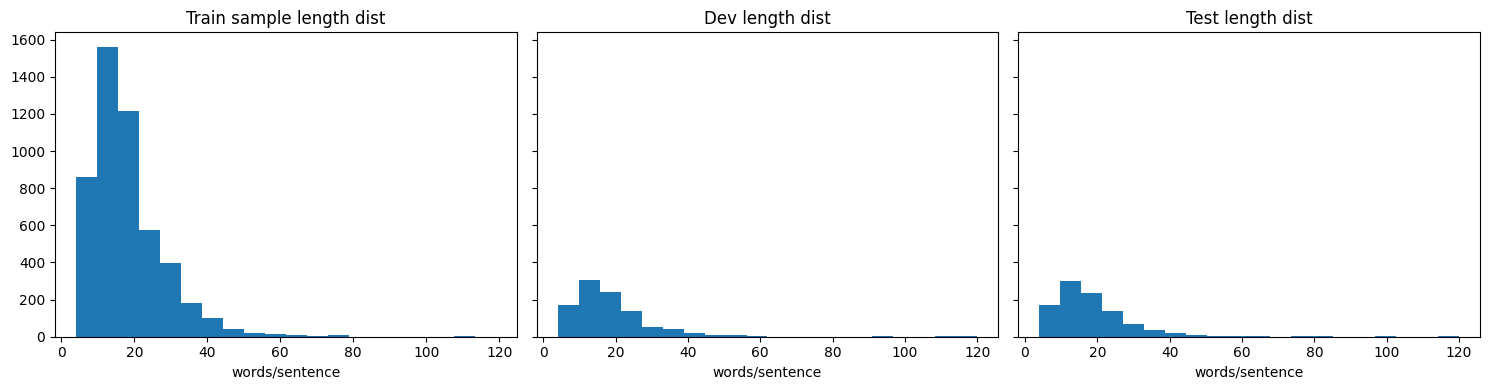

In [ ]:
# Sanity check: length distributions of dev/test should span a wide range, not cluster
def length_stats(sents, name):
    lens = [word_count(s) for s in sents]
    print(f"{name}: min={min(lens)} max={max(lens)} mean={sum(lens)/len(lens):.1f}")
    return lens

train_lens = length_stats(train_sentences[:5000], "Train (sample)")
dev_lens   = length_stats(dev_sentences, "Dev")
test_lens  = length_stats(test_sentences, "Test")

fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
ax[0].hist(train_lens, bins=20); ax[0].set_title("Train sample length dist")
ax[1].hist(dev_lens, bins=20);   ax[1].set_title("Dev length dist")
ax[2].hist(test_lens, bins=20);  ax[2].set_title("Test length dist")
for a in ax: a.set_xlabel("words/sentence")
plt.tight_layout(); plt.show()


In [ ]:
# Persist splits to disk (one sentence per line)
def save_lines(path, lines):
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

save_lines(f"{OUT_DIR}/train.txt", train_sentences)
save_lines(f"{OUT_DIR}/dev.txt", dev_sentences)
save_lines(f"{OUT_DIR}/test.txt", test_sentences)

print("Saved train/dev/test to", OUT_DIR)


Saved train/dev/test to indiccorp_data


## 5. Tokenizer training functions

We use HuggingFace `tokenizers` (fast, production BPE/WordPiece trainers) — same underlying
algorithms as a from-scratch implementation, but tractable at 1M-sentence scale.

In [ ]:
def build_bpe_tokenizer(train_lines, vocab_size):
    tok = Tokenizer(BPE(unk_token="[UNK]"))
    tok.normalizer = normalizers.NFKC()
    tok.pre_tokenizer = pre_tokenizers.Whitespace()
    tok.decoder = decoders.BPEDecoder()

    trainer = BpeTrainer(
        vocab_size=vocab_size,
        min_frequency=2,
        special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
    )
    tok.train_from_iterator(train_lines, trainer=trainer)
    return tok


def build_wordpiece_tokenizer(train_lines, vocab_size):
    tok = Tokenizer(WordPiece(unk_token="[UNK]"))
    tok.normalizer = normalizers.NFKC()
    tok.pre_tokenizer = pre_tokenizers.Whitespace()
    tok.decoder = decoders.WordPiece()

    trainer = WordPieceTrainer(
        vocab_size=vocab_size,
        min_frequency=2,
        special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
    )
    tok.train_from_iterator(train_lines, trainer=trainer)
    return tok


## 6. Evaluation function

For a trained tokenizer we report, on a given sentence set:
- average tokens per sentence
- fertility = avg tokens per whitespace word (how much a word gets split)
- % of tokens that are `[UNK]`
- final learned vocab size

In [ ]:
def evaluate_tokenizer(tok, sentences):
    total_tokens = 0
    total_words = 0
    unk_count = 0
    unk_id = tok.token_to_id("[UNK]")

    for s in sentences:
        enc = tok.encode(s)
        total_tokens += len(enc.ids)
        total_words += len(s.split())
        unk_count += sum(1 for i in enc.ids if i == unk_id)

    return {
        "vocab_size": tok.get_vocab_size(),
        "avg_tokens_per_sentence": total_tokens / len(sentences),
        "fertility_tokens_per_word": total_tokens / total_words,
        "unk_rate_pct": 100 * unk_count / total_tokens if total_tokens else 0.0,
    }


## 7. Task 3 — Effect of training data size

Fixed vocab size = `DEFAULT_VOCAB_SIZE`. Train BPE + WordPiece on increasing amounts of training
data and evaluate on dev + test.

In [ ]:
size_results = []

for size in TRAIN_SIZES:
    subset = train_sentences[:min(size, len(train_sentences))]
    print(f"\n=== Training size: {len(subset)} sentences ===")

    bpe_tok = build_bpe_tokenizer(subset, DEFAULT_VOCAB_SIZE)
    wp_tok  = build_wordpiece_tokenizer(subset, DEFAULT_VOCAB_SIZE)

    for name, tok in [("BPE", bpe_tok), ("WordPiece", wp_tok)]:
        dev_m  = evaluate_tokenizer(tok, dev_sentences)
        test_m = evaluate_tokenizer(tok, test_sentences)
        size_results.append({
            "train_size": len(subset), "model": name, "split": "dev", **dev_m
        })
        size_results.append({
            "train_size": len(subset), "model": name, "split": "test", **test_m
        })

size_df = pd.DataFrame(size_results)
size_df



=== Training size: 100000 sentences ===

=== Training size: 300000 sentences ===

=== Training size: 500000 sentences ===

=== Training size: 931489 sentences ===


,train_size,model,split,vocab_size,avg_tokens_per_sentence,fertility_tokens_per_word,unk_rate_pct
0,100000,BPE,dev,30000,21.632,1.154446,0.004623
1,100000,BPE,test,30000,21.809,1.163892,0.000000
2,100000,WordPiece,dev,30000,21.787,1.162717,0.004590
3,100000,WordPiece,test,30000,21.963,1.172110,0.000000
4,300000,BPE,dev,30000,21.558,1.150496,0.000000
5,300000,BPE,test,30000,21.737,1.160049,0.000000
6,300000,WordPiece,dev,30000,21.744,1.160423,0.000000
7,300000,WordPiece,test,30000,21.931,1.170402,0.000000
8,500000,BPE,dev,30000,21.551,1.150123,0.000000
9,500000,BPE,test,30000,21.727,1.159515,0.000000


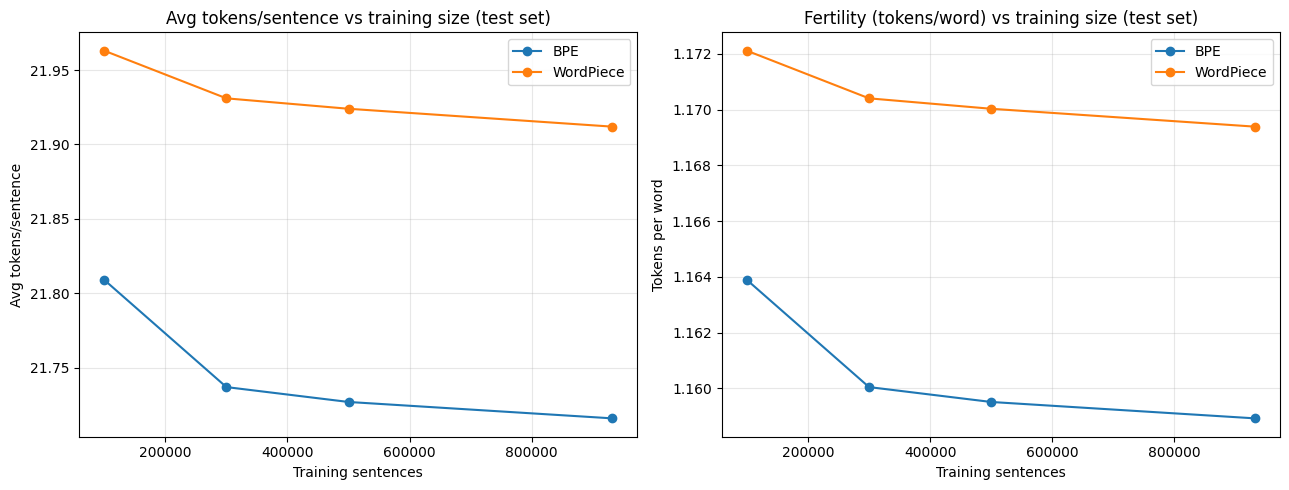

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model in ["BPE", "WordPiece"]:
    sub = size_df[(size_df.model == model) & (size_df.split == "test")]
    axes[0].plot(sub.train_size, sub.avg_tokens_per_sentence, marker="o", label=model)
    axes[1].plot(sub.train_size, sub.fertility_tokens_per_word, marker="o", label=model)

axes[0].set_title("Avg tokens/sentence vs training size (test set)")
axes[0].set_xlabel("Training sentences"); axes[0].set_ylabel("Avg tokens/sentence")
axes[1].set_title("Fertility (tokens/word) vs training size (test set)")
axes[1].set_xlabel("Training sentences"); axes[1].set_ylabel("Tokens per word")
for a in axes: a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Task 4 — Effect of vocabulary size

Fixed training size = `min(DEFAULT_TRAIN_SIZE, len(train_sentences))`. Vary vocab size and evaluate.

In [ ]:
vocab_results = []
fixed_subset = train_sentences[:min(DEFAULT_TRAIN_SIZE, len(train_sentences))]
print(f"Using {len(fixed_subset)} training sentences for vocab-size comparison")

for vsize in VOCAB_SIZES:
    print(f"\n=== Vocab size: {vsize} ===")

    bpe_tok = build_bpe_tokenizer(fixed_subset, vsize)
    wp_tok  = build_wordpiece_tokenizer(fixed_subset, vsize)

    for name, tok in [("BPE", bpe_tok), ("WordPiece", wp_tok)]:
        dev_m  = evaluate_tokenizer(tok, dev_sentences)
        test_m = evaluate_tokenizer(tok, test_sentences)
        vocab_results.append({
            "target_vocab_size": vsize, "model": name, "split": "dev", **dev_m
        })
        vocab_results.append({
            "target_vocab_size": vsize, "model": name, "split": "test", **test_m
        })

vocab_df = pd.DataFrame(vocab_results)
vocab_df


Using 931489 training sentences for vocab-size comparison

=== Vocab size: 20000 ===

=== Vocab size: 30000 ===

=== Vocab size: 50000 ===


,target_vocab_size,model,split,vocab_size,avg_tokens_per_sentence,fertility_tokens_per_word,unk_rate_pct
0,20000,BPE,dev,20000,22.074,1.178034,0.0
1,20000,BPE,test,20000,22.293,1.189721,0.0
2,20000,WordPiece,dev,20000,22.387,1.194738,0.0
3,20000,WordPiece,test,20000,22.626,1.207493,0.0
4,30000,BPE,dev,30000,21.542,1.149642,0.0
5,30000,BPE,test,30000,21.716,1.158928,0.0
6,30000,WordPiece,dev,30000,21.728,1.159569,0.0
7,30000,WordPiece,test,30000,21.912,1.169388,0.0
8,50000,BPE,dev,50000,21.118,1.127015,0.0
9,50000,BPE,test,50000,21.284,1.135874,0.0


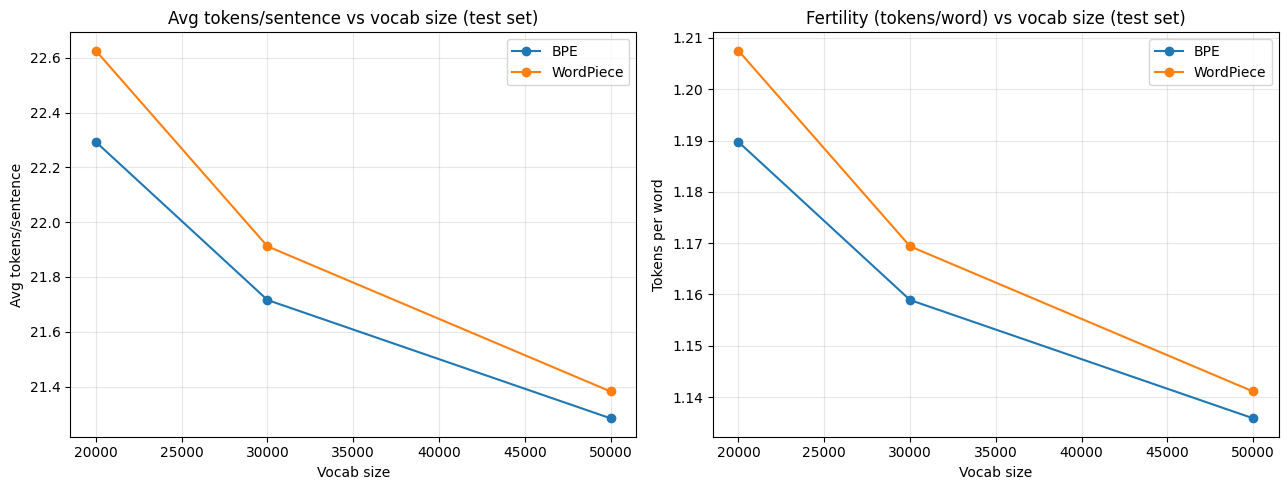

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model in ["BPE", "WordPiece"]:
    sub = vocab_df[(vocab_df.model == model) & (vocab_df.split == "test")]
    axes[0].plot(sub.target_vocab_size, sub.avg_tokens_per_sentence, marker="o", label=model)
    axes[1].plot(sub.target_vocab_size, sub.fertility_tokens_per_word, marker="o", label=model)

axes[0].set_title("Avg tokens/sentence vs vocab size (test set)")
axes[0].set_xlabel("Vocab size"); axes[0].set_ylabel("Avg tokens/sentence")
axes[1].set_title("Fertility (tokens/word) vs vocab size (test set)")
axes[1].set_xlabel("Vocab size"); axes[1].set_ylabel("Tokens per word")
for a in axes: a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Qualitative check — sample tokenizations

Sanity-check output on a few dev sentences using the largest-vocab, full-data models.

In [ ]:
bpe_final = build_bpe_tokenizer(fixed_subset, max(VOCAB_SIZES))
wp_final  = build_wordpiece_tokenizer(fixed_subset, max(VOCAB_SIZES))

for s in dev_sentences[:5]:
    print("SENT :", s)
    print("BPE  :", bpe_final.encode(s).tokens)
    print("WP   :", wp_final.encode(s).tokens)
    print("-" * 80)


SENT : उन्होंने कहा कि वह कैबिनेट के अपने संबंधित साथियों के सामने यह मसला उठायेंगे.
BPE  : ['उन्होंने', 'कहा', 'कि', 'वह', 'कैबिनेट', 'के', 'अपने', 'संबंधित', 'साथियों', 'के', 'सामने', 'यह', 'मसला', 'उठा', 'येंगे', '.']
WP   : ['उन्होंने', 'कहा', 'कि', 'वह', 'कैबिनेट', 'के', 'अपने', 'संबंधित', 'साथियों', 'के', 'सामने', 'यह', 'मसला', 'उठाये', '##ंगे', '.']
--------------------------------------------------------------------------------
SENT : जब वे एटीएम खोलने गए और विशेष तरीके से पैसे अंदर डाले तो वे चौंक गए।
BPE  : ['जब', 'वे', 'एटीएम', 'खोलने', 'गए', 'और', 'विशेष', 'तरीके', 'से', 'पैसे', 'अंदर', 'डाले', 'तो', 'वे', 'चौंक', 'गए', '।']
WP   : ['जब', 'वे', 'एटीएम', 'खोलने', 'गए', 'और', 'विशेष', 'तरीके', 'से', 'पैसे', 'अंदर', 'डाले', 'तो', 'वे', 'चौंक', 'गए', '।']
--------------------------------------------------------------------------------
SENT : हिमाचल के अपने या निजी विश्वविद्यालयों में जाकर सुनें कि वहां यू ट्यूब पर चलते हिमाचली गाने की तान पर बाहरी राज्यों के छात्र क्यों झूम रहे

In [ ]:
# Save result tables + final tokenizers for the report
size_df.to_csv(f"{OUT_DIR}/results_by_train_size.csv", index=False)
vocab_df.to_csv(f"{OUT_DIR}/results_by_vocab_size.csv", index=False)

bpe_final.save(f"{OUT_DIR}/bpe_tokenizer.json")
wp_final.save(f"{OUT_DIR}/wordpiece_tokenizer.json")

print("Saved results and final tokenizers to", OUT_DIR)


Saved results and final tokenizers to indiccorp_data


## 10. Observations (fill in after running)

- **Training size (Task 3):** As training data grows, both BPE and WordPiece learn more frequent
  multi-character/whole-word merges, so avg tokens/sentence and fertility should *decrease* and
  then plateau once the vocab is saturated with common subwords.
- **Vocab size (Task 4):** Larger vocab → more whole words get their own token → fewer splits →
  lower fertility, but diminishing returns past a point, and larger vocab = larger embedding table
  in any downstream model.
- **BPE vs WordPiece:** WordPiece's likelihood-based merge criterion (vs BPE's frequency-based one)
  typically yields slightly different segmentations for morphologically rich languages like Hindi;
  compare the qualitative examples in Section 9 to see this directly on your data.
